In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/galibamin/vgg16/keras/default/1/20epochvgg16model.keras
/kaggle/input/models/galibamin/resnet50-plant-disease/keras/default/1/100epochrenet.keras
/kaggle/input/models/galibamin/mobilenetv2/keras/default/1/mobilenet_best.keras
/kaggle/input/models/galibamin/efficentnet/keras/default/1/30eppochefficientnet.keras
/kaggle/input/plantvillage/Plant_leave_diseases_dataset_without_augmentation/Corn___Northern_Leaf_Blight/image (849).jpg
/kaggle/input/plantvillage/Plant_leave_diseases_dataset_without_augmentation/Corn___Northern_Leaf_Blight/image (276).JPG
/kaggle/input/plantvillage/Plant_leave_diseases_dataset_without_augmentation/Corn___Northern_Leaf_Blight/image (971).jpg
/kaggle/input/plantvillage/Plant_leave_diseases_dataset_without_augmentation/Corn___Northern_Leaf_Blight/image (864).JPG
/kaggle/input/plantvillage/Plant_leave_diseases_dataset_without_augmentation/Corn___Northern_Leaf_Blight/image (282).JPG
/kaggle/input/plantvillage/Plant_leave_diseases_dataset_withou

KeyboardInterrupt: 

In [1]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [3]:
import tensorflow as tf
import pandas as pd
import os

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [5]:
from tensorflow.keras.applications import ResNet50

In [6]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [7]:


base_path = "../input/plantvillage/"

# This will list the folder(s) inside
print(os.listdir(base_path))

['Plant_leave_diseases_dataset_without_augmentation']


In [8]:
dataset_dir = "../input/plantvillage/Plant_leave_diseases_dataset_without_augmentation" 

# 2. Check the contents (This will now work)
print(f"Loading images from: {dataset_dir}")
print(os.listdir(dataset_dir)[:5])

Loading images from: ../input/plantvillage/Plant_leave_diseases_dataset_without_augmentation
['Corn___Northern_Leaf_Blight', 'Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)']


In [9]:
data=ImageDataGenerator(
    rescale=1./255,  #normalized to 0-1
    validation_split=0.2  #20% for validation
)

In [10]:
Train_data=data.flow_from_directory(
    directory=dataset_dir,
    batch_size=32,
    target_size=(256,256),
    shuffle=True,
    class_mode='categorical',
    subset='training'

)

validation_data=data.flow_from_directory(
    directory=dataset_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'

)

Found 44371 images belonging to 39 classes.
Found 11077 images belonging to 39 classes.


In [15]:
pmodel=ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(256,256,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
for layer in pmodel.layers:
    layer.trainable = False

In [17]:
x=pmodel.output
x=GlobalAveragePooling2D()(x)
x=Dense(512,activation='relu')(x)
x=Dense(39,activation='softmax')(x)

In [18]:
fmodel=Model(inputs=pmodel.input,outputs=x)

In [ ]:


early_stop = EarlyStopping(patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [19]:
fmodel.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
import os
from tensorflow.keras.models import load_model

# Paste the folder path from Kaggle, then add the filename
model_path = "/kaggle/input/models/galibamin/resnet50-plant-disease/keras/default/1/100epochrenet.keras"

if os.path.exists(model_path):
    print(f"Found model at: {model_path}")
    resnet_model = load_model(model_path)
    print("Model loaded successfully!")
else:
    print("File not found. Available files:")
    # This will help you see exactly what's there
    for root, dirs, files in os.walk("/kaggle/input/models/galibamin/resnet50-plant-disease/"):
        for file in files:
            print(os.path.join(root, file))

Found model at: /kaggle/input/models/galibamin/resnet50-plant-disease/keras/default/1/100epochrenet.keras
Model loaded successfully!


In [28]:
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 26,794,999 (102.21 MB)

 Trainable params: 1,069,095 (4.08 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 2,138,192 (8.16 MB)

In [20]:
import time

start = time.time()

fmodel.fit(
    Train_data,
    validation_data=validation_data,
    epochs=1
)

end = time.time()

time_per_epoch = end - start
estimated_time = (time_per_epoch * 100) / 60

print("Time per epoch:", time_per_epoch)
print("Estimated total training time (100 epochs):", estimated_time, "minutes")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1776712645.284859     145 service.cc:148] XLA service 0x7865e0003d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776712645.285566     145 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776712646.754937     145 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1387 ━━━━━━━━━━━━━━━━━━━━ 1:22 60ms/step - accuracy: 0.0000e+00 - loss: 4.1502  

I0000 00:00:1776712650.553119     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 456s 318ms/step - accuracy: 0.1646 - loss: 3.2796 - val_accuracy: 0.2450 - val_loss: 2.9002
Time per epoch: 456.3049874305725
Estimated total training time (100 epochs): 760.5083123842875 minutes


In [21]:
result_resnet = {
    "Model": "ResNet50",
    "Time per Epoch (sec)": 456.30,
    "Training Time (min)": 760.50
}

print(result_resnet)

{'Model': 'ResNet50', 'Time per Epoch (sec)': 456.3, 'Training Time (min)': 760.5}


In [29]:
print(resnet_model.input_shape)

(None, 256, 256, 3)


In [31]:
loss, train_acc = resnet_model.evaluate(Train_data)

print("Training Accuracy:", train_acc)

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 106s 72ms/step - accuracy: 0.7417 - loss: 0.8636
Training Accuracy: 0.7451263070106506


In [32]:
loss, accuracy = resnet_model.evaluate(validation_data)
print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

347/347 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.7218 - loss: 0.9631
Validation Accuracy: 0.7344949245452881
Validation Loss: 0.9136368632316589


In [34]:
import matplotlib.pyplot as plt

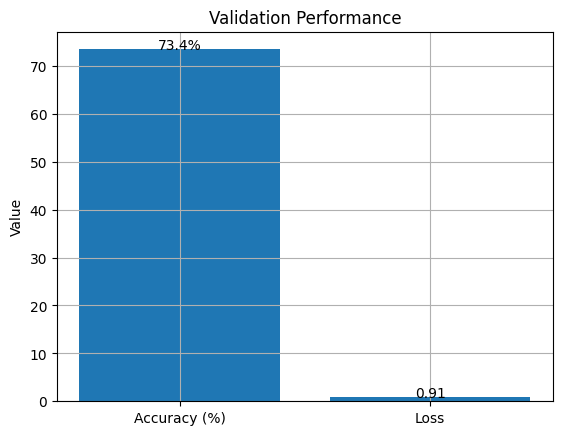

In [36]:
plt.figure()

plt.bar(["Accuracy (%)", "Loss"], [accuracy*100, loss])

plt.title("Validation Performance")
plt.ylabel("Value")

plt.text(0, accuracy*100, f"{accuracy*100:.1f}%", ha='center')
plt.text(1, loss, f"{loss:.2f}", ha='center')
plt.grid()
plt.show()

In [38]:
import numpy as np

y_pred = resnet_model.predict(validation_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = validation_data.classes

347/347 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.36      0.06      0.11       126
           1       0.66      0.80      0.72       124
           2       0.47      0.25      0.33        55
           3       0.57      0.72      0.63       329
           4       0.89      0.89      0.89       228
           5       0.63      0.75      0.68       300
           6       0.70      0.68      0.69       210
           7       0.79      0.81      0.80       170
           8       0.82      0.40      0.54       102
           9       0.96      0.94      0.95       238
          10       0.64      0.82      0.72       197
          11       0.87      0.84      0.85       232
          12       0.65      0.81      0.72       236
          13       0.80      0.80      0.80       276
          14       0.85      0.73      0.78       215
          15       0.71      0.81      0.76        84
          16       0.83      0.95      0.89      1101
          17       0.62    

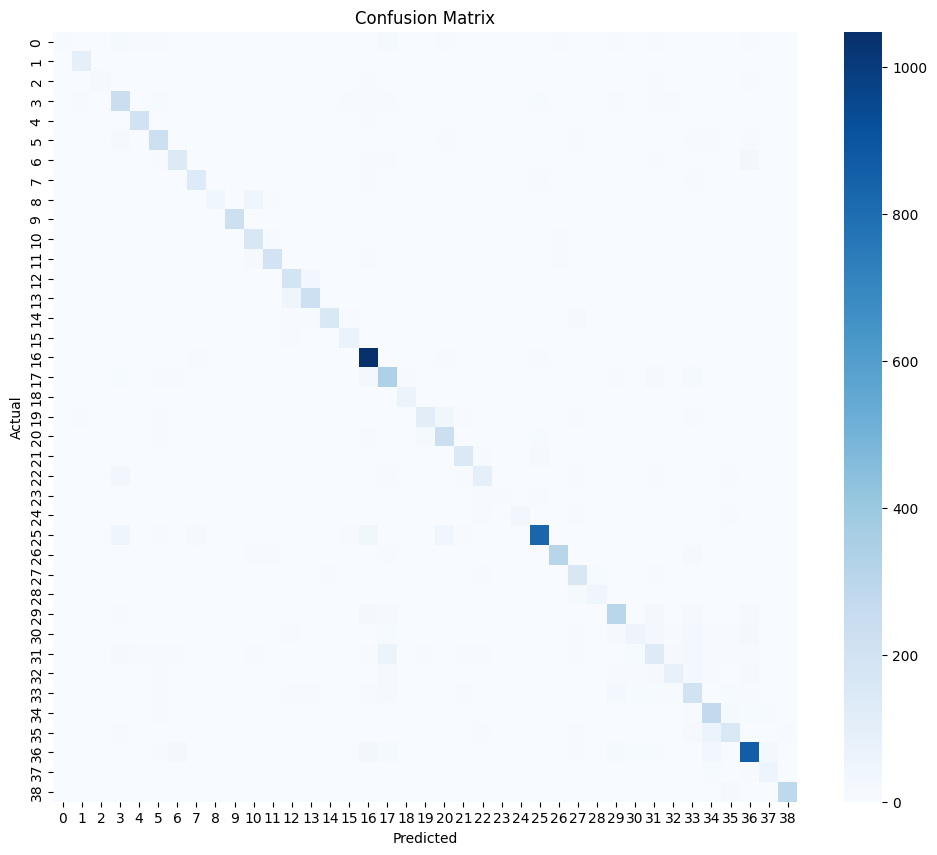

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
import time

start = time.time()
resnet_model.predict(validation_data)
end = time.time()

print("Prediction Time:", end - start)

347/347 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step
Prediction Time: 24.54973292350769


In [ ]:
#VGG16

In [43]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [44]:
print("Setting up training data generator for vgg16...")
train_data_gen = data.flow_from_directory(
    directory=dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'  
)

print("Setting up validation data generator for vgg16...")
val_data_gen = data.flow_from_directory(
    directory=dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation' 
)

print(f"\nSetup complete. Found {train_data_gen.num_classes} classes.")

Setting up training data generator for vgg16...
Found 44371 images belonging to 39 classes.
Setting up validation data generator for vgg16...
Found 11077 images belonging to 39 classes.

Setup complete. Found 39 classes.


In [45]:
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [46]:
for layer in vgg_model.layers:
    layer.trainable = False

In [47]:
final_vgg_model = Sequential([
    vgg_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(39, activation='softmax') 
])

In [58]:
final_vgg_model .compile(
     optimizer=Adam(learning_rate=0.0001),
     loss='categorical_crossentropy',
     metrics=['accuracy']
)

In [ ]:
Train_VGG = final_vgg_model.fit(
    train_data_gen,
    validation_data=val_data_gen,
    epochs=20
)

In [ ]:
print(final_vgg_model.summary())

The model is already trained earlier, now just uploading the model below


In [52]:
import os
from tensorflow.keras.models import load_model

# Paste the folder path from Kaggle, then add the filename
model_path = "/kaggle/input/models/galibamin/vgg16/keras/default/1/20epochvgg16model.keras"

if os.path.exists(model_path):
    print(f"Found model at: {model_path}")
    Vgg_model = load_model(model_path)
    print("Model loaded successfully!")
else:
    print("File not found. Available files:")
    # This will help you see exactly what's there
    for root, dirs, files in os.walk("/kaggle/input/models/galibamin/vgg16/"):
        for file in files:
            print(os.path.join(root, file))

Found model at: /kaggle/input/models/galibamin/vgg16/keras/default/1/20epochvgg16model.keras
Model loaded successfully!


In [53]:
Vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 39)             │        10,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,013,111 (129.75 MB)

 Trainable params: 6,432,807 (24.54 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 12,865,616 (49.08 MB)

In [73]:
print(Vgg_model.input_shape)

(None, 224, 224, 3)


In [54]:
#for time

import time

start = time.time()

final_vgg_model.fit(
    train_data_gen,
    validation_data=val_data_gen,
    epochs=1
)
end = time.time()

time_per_epoch = end - start
estimated_time = (time_per_epoch * 20) / 60

print(f"Time per epoch: {time_per_epoch:.2f} sec")
print("Estimated total training time (20 epochs):", estimated_time, "minutes")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 163s 111ms/step - accuracy: 0.6055 - loss: 1.5410 - val_accuracy: 0.9056 - val_loss: 0.3557
Time per epoch: 163.43 sec
Estimated total training time (20 epochs): 54.47770428657532 minutes


In [61]:
loss, train_acc = Vgg_model.evaluate(train_data_gen)

print("Training Accuracy:", train_acc)

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 104s 74ms/step - accuracy: 0.9996 - loss: 0.0061
Training Accuracy: 0.9994816184043884


In [64]:
loss, accuracy = Vgg_model.evaluate(val_data_gen)
print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

347/347 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.9643 - loss: 0.1174
Validation Accuracy: 0.9660558104515076
Validation Loss: 0.10963699221611023


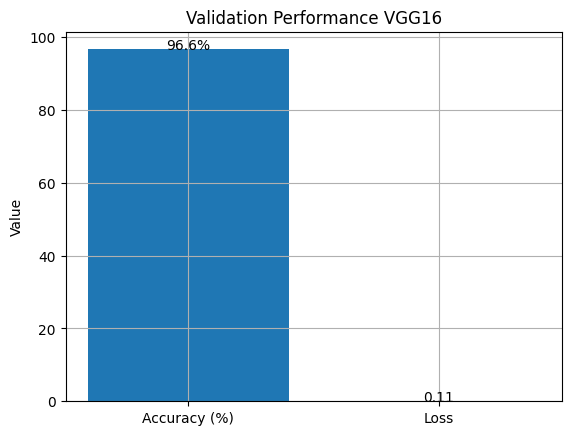

In [65]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(["Accuracy (%)", "Loss"], [accuracy*100, loss])

plt.title("Validation Performance VGG16")
plt.ylabel("Value")

plt.text(0, accuracy*100, f"{accuracy*100:.1f}%", ha='center')
plt.text(1, loss, f"{loss:.2f}", ha='center')
plt.grid()
plt.show()

In [67]:
import numpy as np

y_pred = Vgg_model.predict(val_data_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data_gen.classes

347/347 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.03      0.03      0.03       126
           1       0.02      0.02      0.02       124
           2       0.00      0.00      0.00        55
           3       0.02      0.02      0.02       329
           4       0.02      0.02      0.02       228
           5       0.02      0.02      0.02       300
           6       0.02      0.02      0.02       210
           7       0.01      0.01      0.01       170
           8       0.01      0.01      0.01       102
           9       0.03      0.03      0.03       238
          10       0.01      0.01      0.01       197
          11       0.03      0.03      0.03       232
          12       0.03      0.03      0.03       236
          13       0.02      0.03      0.03       276
          14       0.00      0.00      0.00       215
          15       0.00      0.00      0.00        84
          16       0.10      0.10      0.10      1101
          17       0.05    

100 epochs with early stopping VGG16

In [ ]:
import time
from tensorflow.keras.callbacks import Callback

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):   #for time
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.epoch_time_start)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

time_callback = TimeHistory()

In [ ]:
start_time = time.time()

history = final_vgg_model.fit(
    train_data_gen,
    validation_data=val_data_gen,
    epochs=100,
    callbacks=[early_stop, reduce_lr, checkpoint, time_callback]
)

end_time = time.time()

In [ ]:
total_time = end_time - start_time
avg_epoch_time = sum(time_callback.times) / len(time_callback.times)

print(f"Total Training Time: {total_time/60:.2f} minutes")
print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")
print(f"Total Epochs Run: {len(time_callback.times)}")

In [ ]:
#for full epoch
estimated_total = avg_epoch_time * 100
print(f"Estimated Time for 100 Epochs: {estimated_total/60:.2f} minutes")

In [ ]:
import os
print(os.listdir("/kaggle/working"))

In [ ]:

os.rename("/kaggle/working/best_model.keras",
          "/kaggle/working/VGG16_best.keras")

In [ ]:
print(os.listdir("/kaggle/working"))

In [ ]:
from tensorflow.keras.models import load_model

vgg_model_38epoch = load_model("/kaggle/working/VGG16_best.keras")

In [ ]:
vgg_model_38epoch.summary()

In [ ]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy (VGG16)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
labels = ["Training Accuracy", "Validation Accuracy"]
values = [train_acc[-1] * 100, val_acc[-1] * 100]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(labels, values)

plt.title("Final Accuracy Comparison (VGG16)")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)  # optional but recommended

plt.show()

In [ ]:
import numpy as np

y_pred = vgg_model_38epoch.predict(val_data_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data_gen.classes

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

In [ ]:
file_path = '/kaggle/working/20epochvgg16model.keras'


final_vgg_model.save(file_path)

print(f"Model saved successfully to: {file_path}")

In [ ]:
file_path = '/kaggle/working/20epochrenet.keras'


fmodel.save(file_path)

print(f"Model saved successfully to: {file_path}")

In [ ]:
model_path=("C:/Users/ghali/Downloads/100epochrenet.keras")


In [ ]:
#mobilenetv2 Final

In [69]:


import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


In [71]:
import time
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [72]:
data = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

mob_train_data = data.flow_from_directory(
    directory=dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

mob_validation_data = data.flow_from_directory(
    directory=dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)


Found 44371 images belonging to 39 classes.
Found 11077 images belonging to 39 classes.


In [74]:
import os
from tensorflow.keras.models import load_model

# Paste the folder path from Kaggle, then add the filename
model_path = "/kaggle/input/models/galibamin/mobilenetv2/keras/default/1/mobilenet_best.keras"

if os.path.exists(model_path):
    print(f"Found model at: {model_path}")
    mobilenet_model = load_model(model_path)
    print("Model loaded successfully!")
else:
    print("File not found. Available files:")
    # This will help you see exactly what's there
    for root, dirs, files in os.walk("/kaggle/input/models/galibamin/mobilenetv2/"):
        for file in files:
            print(os.path.join(root, file))

Found model at: /kaggle/input/models/galibamin/mobilenetv2/keras/default/1/mobilenet_best.keras
Model loaded successfully!


In [100]:
print('mobilenet_model.input_shape()')

mobilenet_model.input_shape()


In [76]:
mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,271,863 (12.48 MB)

 Trainable params: 337,959 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 675,920 (2.58 MB)

In [77]:
loss, train_acc = mobilenet_model.evaluate(mob_train_data)

print("Training Accuracy:", train_acc)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 95s 63ms/step - accuracy: 0.9984 - loss: 0.0142
Training Accuracy: 0.9982871413230896


In [78]:
loss, accuracy = mobilenet_model.evaluate(mob_validation_data)
print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

347/347 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9768 - loss: 0.0724
Validation Accuracy: 0.9698474407196045
Validation Loss: 0.09147623926401138


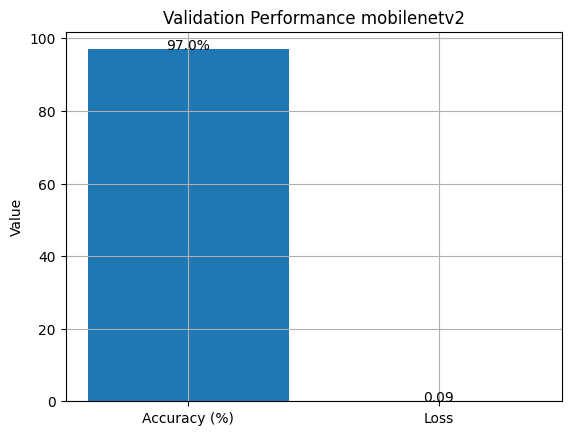

In [79]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(["Accuracy (%)", "Loss"], [accuracy*100, loss])

plt.title("Validation Performance mobilenetv2")
plt.ylabel("Value")

plt.text(0, accuracy*100, f"{accuracy*100:.1f}%", ha='center')
plt.text(1, loss, f"{loss:.2f}", ha='center')
plt.grid()
plt.show()

In [87]:
import numpy as np

moby_pred = mobilenet_model.predict(mob_validation_data)
moby_pred_classes = np.argmax(moby_pred, axis=1)

moby_true = mob_validation_data.classes

347/347 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step


In [88]:
from sklearn.metrics import classification_report

print(classification_report(moby_true, moby_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       126
           1       0.98      0.98      0.98       124
           2       1.00      0.98      0.99        55
           3       0.98      0.99      0.98       329
           4       0.99      0.98      0.98       228
           5       0.98      0.99      0.99       300
           6       1.00      0.99      1.00       210
           7       1.00      0.98      0.99       170
           8       0.88      0.82      0.85       102
           9       1.00      0.99      0.99       238
          10       0.90      0.93      0.92       197
          11       1.00      1.00      1.00       232
          12       0.97      0.97      0.97       236
          13       0.98      0.98      0.98       276
          14       1.00      1.00      1.00       215
          15       1.00      0.99      0.99        84
          16       1.00      1.00      1.00      1101
          17       0.99    

The trained model using early stopping 100 epoch






In [ ]:
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.start)

In [ ]:


base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(39, activation='softmax')(x)


In [ ]:
mobilenetV2_model = Model(inputs=base_model.input, outputs=output)


In [ ]:
mobilenetV2_model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
time_callback = TimeHistory()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
checkpoint = ModelCheckpoint("mobilenet_best.keras", monitor='val_loss', save_best_only=True, verbose=1)


In [ ]:
start = time.time()

history_mobilenetV2_model = mobilenetV2_model.fit(
    mob_train_data,
    validation_data=mob_validation_data,
    epochs=100,
    callbacks=[early_stop, reduce_lr, checkpoint, time_callback]
)

end = time.time()

In [ ]:
import os
print(os.listdir("/kaggle/working"))

In [ ]:
total_time = end - start
avg_epoch_time = sum(time_callback.times) / len(time_callback.times)

print(f"Total Training Time: {total_time/60:.2f} minutes")
print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")
print(f"Total Epochs Run: {len(time_callback.times)}")

In [ ]:
#for full epoch
estimated_total = avg_epoch_time * 100
print(f"Estimated Time for 100 Epochs: {estimated_total/60:.2f} minutes")

In [ ]:
from tensorflow.keras.models import load_model

mobilenetv2 = load_model("/kaggle/working/mobilenet_best.keras")

In [ ]:
mobilenetv2.summary()

In [ ]:
mbl_train_acc = history_mobilenetV2_model.history['accuracy']
mbl_val_acc = history_mobilenetV2_model.history['val_accuracy']

print("Final Training Accuracy:", mbl_train_acc[-1])
print("Final Validation Accuracy:",mbl_val_acc[-1])

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(mbl_train_acc, label="Training Accuracy")
plt.plot(mbl_val_acc, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy (VGG16)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
labels = ["Training Accuracy", "Validation Accuracy"]
values = [mbl_train_acc[-1] * 100, mbl_val_acc[-1] * 100]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(labels, values)

plt.title("Final Accuracy Comparison (VGG16)")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)  # optional but recommended
plt.grid()
plt.show()

In [ ]:
import numpy as np

y_pred = mobilenetv2.predict(mob_validation_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = mob_validation_data.classes

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

In [ ]:
#Efficientnet

In [89]:

from tensorflow.keras.applications import EfficientNetB0


In [90]:

eff_train_data = data.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

eff_validation_data = data.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 44371 images belonging to 39 classes.
Found 11077 images belonging to 39 classes.


In [91]:
eff_base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [93]:
for layer in eff_base_model.layers:
    layer.trainable = False


In [95]:
x = eff_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(39, activation='softmax')(x)

eff_model = Model(inputs=eff_base_model.input, outputs=output)


In [97]:
eff_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)




In [ ]:
history = eff_model.fit(
    eff_train_data,
    validation_data=eff_validation_data,
    epochs=10
)

In [ ]:
file_path = '/kaggle/working/10eppochefficientnet.keras'


eff_model.save(file_path)

print(f"Model saved successfully to: {file_path}")

In [ ]:
history2 = eff_model.fit(
    eff_train_data,
    validation_data=eff_validation_data,
    epochs=30,
    initial_epoch=10
)


loading the trained efficientBO model



In [101]:
import os
from tensorflow.keras.models import load_model

# Paste the folder path from Kaggle, then add the filename
model_path = "/kaggle/input/models/galibamin/efficentnet/keras/default/1/30eppochefficientnet.keras"

if os.path.exists(model_path):
    print(f"Found model at: {model_path}")
    efficientbo_model = load_model(model_path)
    print("Model loaded successfully!")
else:
    print("File not found. Available files:")
    # This will help you see exactly what's there
    for root, dirs, files in os.walk("/kaggle/input/models/galibamin/mobilenetv2/"):
        for file in files:
            print(os.path.join(root, file))

Found model at: /kaggle/input/models/galibamin/efficentnet/keras/default/1/30eppochefficientnet.keras
Model loaded successfully!


In [103]:
efficientbo_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,063,450 (19.32 MB)

 Trainable params: 337,959 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 675,920 (2.58 MB)

In [104]:
import time

eff_start = time.time()

eff_model.fit(
    eff_train_data,
    validation_data=eff_validation_data,
    epochs=1
)

eff_end = time.time()

time_per_epoch = eff_end - eff_start
estimated_time = (time_per_epoch * 100) / 60

print("Time per epoch:", time_per_epoch)
print("Estimated total training time (100 epochs):", estimated_time, "minutes")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 151s 91ms/step - accuracy: 0.0896 - loss: 3.4564 - val_accuracy: 0.0967 - val_loss: 3.3818
Time per epoch: 151.6834979057312
Estimated total training time (100 epochs): 252.80582984288534 minutes


In [105]:
time_per_epoch =151.68
epochs = 30

total_time_sec = time_per_epoch * epochs
total_time_min = total_time_sec / 60

print("Total Time (seconds):", total_time_sec)
print("Total Time (minutes):", total_time_min)

Total Time (seconds): 4550.400000000001
Total Time (minutes): 75.84


In [106]:
loss, train_acc = efficientbo_model.evaluate(eff_train_data)

print("Training Accuracy:", train_acc)

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 100s 65ms/step - accuracy: 0.0959 - loss: 3.3708
Training Accuracy: 0.09929908812046051


In [107]:
loss, accuracy = efficientbo_model.evaluate(eff_validation_data)
print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

347/347 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.1102 - loss: 3.6426
Validation Accuracy: 0.09939514100551605
Validation Loss: 3.365701198577881


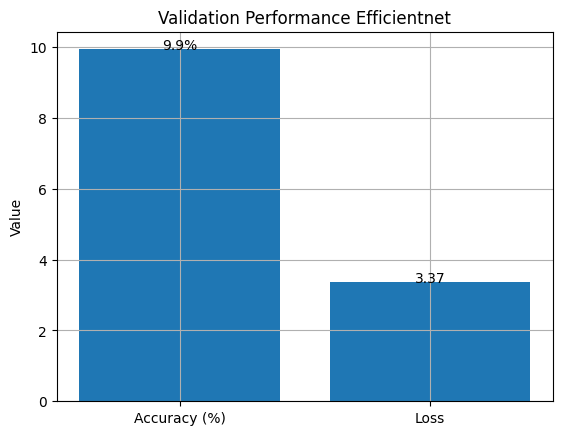

In [108]:
plt.figure()

plt.bar(["Accuracy (%)", "Loss"], [accuracy*100, loss])

plt.title("Validation Performance Efficientnet")
plt.ylabel("Value")

plt.text(0, accuracy*100, f"{accuracy*100:.1f}%", ha='center')
plt.text(1, loss, f"{loss:.2f}", ha='center')

plt.grid()

plt.show()

In [112]:
import numpy as np

effy_pred = efficientbo_model.predict(eff_validation_data)
effy_pred_classes = np.argmax(effy_pred, axis=1)

effy_true = eff_validation_data.classes

347/347 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step


In [113]:
from sklearn.metrics import classification_report

print(classification_report(effy_true, effy_pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       126
           1       0.00      0.00      0.00       124
           2       0.00      0.00      0.00        55
           3       0.00      0.00      0.00       329
           4       0.00      0.00      0.00       228
           5       0.00      0.00      0.00       300
           6       0.00      0.00      0.00       210
           7       0.00      0.00      0.00       170
           8       0.00      0.00      0.00       102
           9       0.00      0.00      0.00       238
          10       0.00      0.00      0.00       197
          11       0.00      0.00      0.00       232
          12       0.00      0.00      0.00       236
          13       0.00      0.00      0.00       276
          14       0.00      0.00      0.00       215
          15       0.00      0.00      0.00        84
          16       0.10      1.00      0.18      1101
          17       0.00    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Final Altogether analysis of 4 pretrained models in googlecollab

